C:\Users\jhans\AppData\Local\Temp\ipykernel_22228\216935655.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_raw, x='Jenis Jasa', y=2020, palette='viridis')


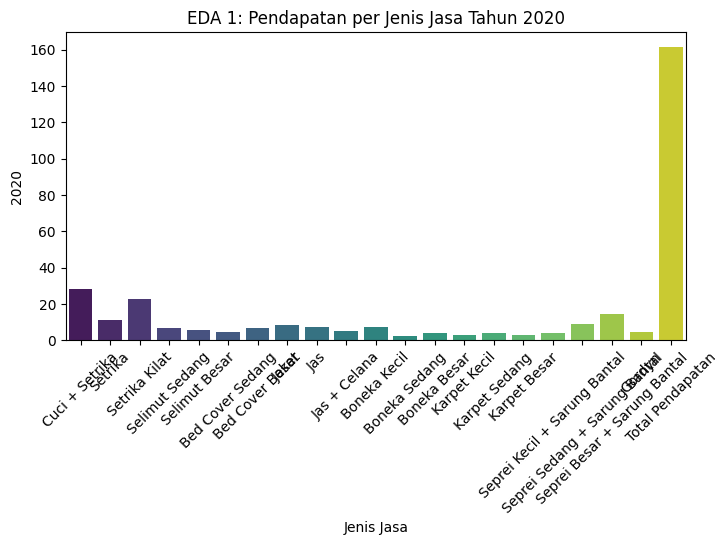

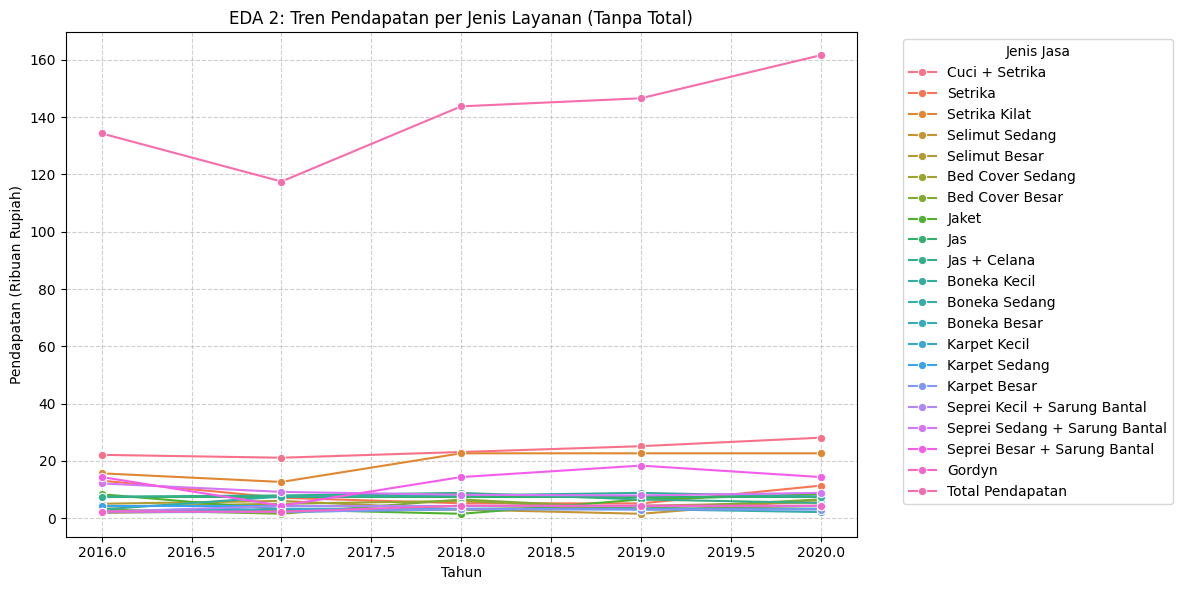

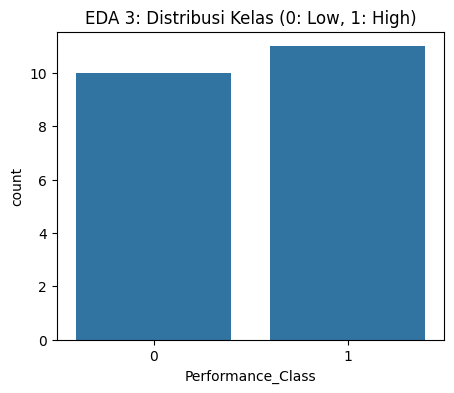


Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



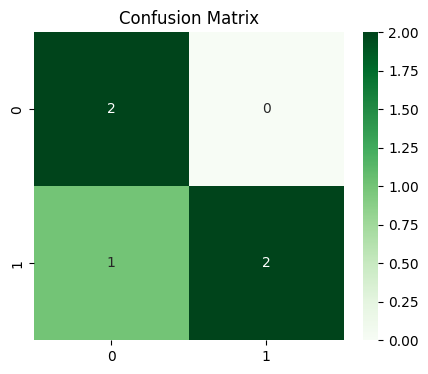

Hasil Prediksi: High-Performing


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# --- 1a. Load Data & EDA ---
file_path = 'dataset_Laundry_PondokSetrika.xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Tabel 3 – Pendapatan per Jenis ')

# EDA 1: Barplot Pendapatan 2020
plt.figure(figsize=(8, 4))
sns.barplot(data=df_raw, x='Jenis Jasa', y=2020, palette='viridis')
plt.title('EDA 1: Pendapatan per Jenis Jasa Tahun 2020')
plt.xticks(rotation=45)
plt.show()

# EDA 2: Tren Pendapatan
# 1. Filter data: Kita hapus baris 'Total' agar tidak merusak skala grafik
df_trend = df_raw[df_raw['Jenis Jasa'] != 'Total'] 

# 2. Re-melt data tanpa baris Total
df_melt = df_trend.melt(id_vars=['Jenis Jasa'], 
                        value_vars=[2016, 2017, 2018, 2019, 2020], 
                        var_name='Tahun', value_name='Pendapatan')

plt.figure(figsize=(12, 6))

# 3. Gunakan marker agar titik tiap tahun terlihat jelas
sns.lineplot(data=df_melt, x='Tahun', y='Pendapatan', hue='Jenis Jasa', marker='o')

plt.title('EDA 2: Tren Pendapatan per Jenis Layanan (Tanpa Total)')
plt.ylabel('Pendapatan (Ribuan Rupiah)')
plt.xlabel('Tahun')

# 4. Pindahkan legenda ke luar grafik agar tidak menutupi garis
plt.legend(title='Jenis Jasa', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Agar layout tidak terpotong karena legenda di luar
plt.show()

# EDA 3: Distribusi Kelas Target (setelah pembuatan target)
median_val = df_raw[2020].median()
df_raw['Performance_Class'] = df_raw[2020].apply(lambda x: 1 if x >= median_val else 0)
plt.figure(figsize=(5, 4))
sns.countplot(x='Performance_Class', data=df_raw)
plt.title('EDA 3: Distribusi Kelas (0: Low, 1: High)')
plt.show()

# --- 1b. Preprocessing ---
# 1. Drop kolom tak relevan
df_ml = df_raw.drop(columns=['No']).dropna()

# 2. Label Encoding
le = LabelEncoder()
df_ml['Jenis_Jasa_Encoded'] = le.fit_transform(df_ml['Jenis Jasa'])

# --- 1c. Feature Extraction ---
# Pilih fitur
X = df_ml[[2016, 2017, 2018, 2019, 'Jenis_Jasa_Encoded']]
y = df_ml['Performance_Class']

# PERBAIKAN: Konversi semua nama kolom ke string untuk StandardScaler
X.columns = X.columns.astype(str)

# 3. Scaling (Preprocessing ke-3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 1e(i). Imbalance Management (Upsampling) ---
X_df = pd.DataFrame(X_scaled, columns=X.columns)
X_df['target'] = y.values
df_low = X_df[X_df.target == 0]
df_high = X_df[X_df.target == 1]

df_low_upsampled = resample(df_low, replace=True, n_samples=len(df_high), random_state=42)
df_balanced = pd.concat([df_high, df_low_upsampled])
X_final = df_balanced.drop('target', axis=1)
y_final = df_balanced['target']

# --- 1d. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# --- 1e(ii). Grid Search ---
param_grid = {
    'n_estimators': [10, 20],
    'max_depth': [None, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=2)
grid_search.fit(X_train, y_train)

# --- 1f. Evaluasi ---
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

# --- 1g. Prediksi Satu Data ---
sample = X_test.iloc[0:1] # Mengambil satu data dari test set
pred = best_model.predict(sample)
print(f"Hasil Prediksi: {'High-Performing' if pred[0] == 1 else 'Low-Performing'}")